In [ ]:
# Script for comparing the TRIBUS and 3 ground truth manually gated samples

In [1]:
import matplotlib.pyplot as plt
#from pyclustree import clustree
import scanpy as sc
import anndata as ad
import pandas as pd
import scimap as sm
import seaborn as sns
import os
import re
from pathlib import Path

Running SCIMAP  2.3.5


/home/iganiemi/anaconda3/envs/cycif_general/lib/python3.10/site-packages/mpl_scatter_density/__init__.py:4: UserWarning:

pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.

/home/iganiemi/anaconda3/envs/cycif_general/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning:

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html



In [32]:
# set up paths
pdrive_mount_dir = "/home/ad/P-drive/h30492/"
#pdrive_mount_dir = "/run/user/1001/gvfs/smb-share:server=group3.ad.helsinki.fi,share=h30492/"

pt_names = ["7-S026_iOme1_01253_4A", "7-S026_iOme2_01253_4A", "7-S046_iOme_01253_4A"]
pt_names_manual_gating = ["S026_1", "S026_2", "S046"] # ensure the same order as pt_names

#pt_names = ["7-S026_iOme1_01253_4A"]
#pt_names_manual_gating = ["S026_1"] # ensure the same order as pt_names

tribus_output_dir = os.path.join(pdrive_mount_dir, "farkkilab2/9_EyeMT/Data_analysis/cycif_processing/phenotyping/tribus_multiple_runs_test/tribus_output_global_stroma_tumor_immune_norm_filt_markers_best_cd20_cd163")
tribus_output_list = [os.path.join(dp, f) for dp, dn, fn in os.walk(os.path.expanduser(tribus_output_dir)) for f in fn]

manual_gating_dir = os.path.join(pdrive_mount_dir, "farkkilab2/7_TLS/Data/Exp_4/cell-phenotyping/gating_results")
manual_gating_filenames = [os.path.join(manual_gating_dir, pt + ".h5ad") for pt in pt_names_manual_gating]

image_dir = os.path.join(pdrive_mount_dir, "farkkilab2/7_TLS/Data/Exp_4/tif")

output_comparison_plots_dir = os.path.join(tribus_output_dir, 'plots_hmap_otherway')

if not os.path.exists(output_comparison_plots_dir):
    os.makedirs(output_comparison_plots_dir)

In [33]:
# have to match selected colnames in tribus input files
# markers_list_colnames = ['PanCK_normalized', 'Vimentin_normalized', 'Iba1_filt_norm', 'CD11c_normalized', 
#                          'CD4_filt_norm', 'CD8a_filt_norm', 'NKGA_filt_norm']

# markers_list_colnames = ['PanCK_normalized', 'Vimentin_normalized', 'Iba1_filt_norm', 'CD11c_normalized', 
#                          'CD4_filt_norm', 'CD8a_filt_norm', 'CD20_filt_norm', 'PAX8_2',
#                             'aSMA_filt_norm','CD31_filt_norm', 'HEV_filt_norm']

# as for manual gating
markers_list_colnames = ['PanCK_normalized', 'Vimentin_normalized', 'Iba1_normalized', 'CD11c_filt_norm', 
                         'CD4_filt_norm', 'CD8a_filt_norm', 'CD20_filt_norm', 'CD163']

# markers_list_colnames = ['PanCK_normalized', 'Vimentin_normalized', 'Iba1_normalized', 'CD11c_filt_norm', 
#                          'CD4_filt_norm', 'CD8a_filt_norm', 'CD20_filt_norm', 'PAX8',
#                             'aSMA_normalized','CD31_filt_norm', 'HEV_filt_norm', 'CD21_filt_norm']

In [18]:
# quick check
pt_nr = 0
manual_gating_file = manual_gating_filenames[pt_nr]
print(manual_gating_file)

# # Read manual gated sample
# sample_data_pt = ad.read_h5ad(manual_gating_file)  

# print(sample_data_pt.obs.shape)

# # categories from Adas manual gating
# print(set(sample_data_pt.obs.phenotype))

# # join with metadata and save as regular csv
# pt_name = pt_names[pt_nr]
# print(pt_name)

# sample_data_pt_obs = sample_data_pt.obs
# sample_data_pt_df = sample_data_pt.to_df()
# sample_data_pt_all = pd.concat([sample_data_pt_obs, sample_data_pt_df], axis=1)

# sample_data_pt_all.to_csv(os.path.join(pdrive_mount_dir, "farkkilab2/9_EyeMT/Data_analysis/cycif_processing/phenotyping/tribus_multiple_runs_test/" + pt_name + '_manual_gating.csv'))

# print('saved')
# check tribus output for pt
# pt_name = pt_names[pt_nr]
# print(pt_name)

# tribus_output_pt = list(filter(re.compile('.*' + pt_name + '.*' + '_tribus_annotation.csv').match, tribus_output_list))
# print(len(tribus_output_pt))
# #print(tribus_output_pt)

# print(tribus_output_pt[2])
# tribus_pt_logic = pd.read_csv(tribus_output_pt[2])
# print(set(tribus_pt_logic.final_label))

# make_umap_w_markers(sample_data, output_comparison_plots_dir, pt_name)


7-S026_iOme1_01253_4A
4
/home/ad/P-drive/h30492/farkkilab2/9_EyeMT/Data_analysis/cycif_processing/phenotyping/tribus_multiple_runs_test/tribus_output_global_stroma_tumor_immune_norm_filt_markers_best/7-S026_iOme1_01253_4Aeyemt_tribus_global_neg_stroma_negimmune_tumor_zero_immune_scrna_zero_nkdrop_tribus_annotation.csv
{'undefined_Global', 'undefined_Stroma', 'undefined_Tumor', 'Stroma_Macrophages', 'Immune_Macrophages', 'Immune_CD8_Tcells', 'undefined_Tumor_Immune', 'Stroma_CD4', 'Stroma_Stroma', 'Immune_CD4_Tcells', 'undefined_Immune', 'Immune_Dcs', 'undefined_Stroma_Immune', 'Tumor_Tumor'}


In [34]:
# dictionary for relabeling: manual gating labels -> tribus labels (what can be matched)
relabel_dict = {
    'CD4+ T cells':'Immune_CD4_Tcells',      
    'CD8+ T cells':'Immune_CD8_Tcells',      
    'CD11c+ DCs':'Immune_Dcs',
    'likely-CD11c+ DCs':'Immune_Dcs', 
    'IBA1+ macrophages':'Immune_Macrophages',
    'CD21+ CD20+ B cells':'Immune_Bcells',
    'CD20+ B cells':'Immune_Bcells',
    'Myeloids2':'Immune_Macrophages',
    
    'CD31+ cells':'Epithelial',
    'HEV+ CD31+ cells':'Epithelial',

    'Stromal':'Stroma',
    'Cancer':'Tumor',
    'Cancer Ki67+':'Tumor',
    'Unknown':'undefined_Global',
}

# dictionary for relabeling tribus labels which doesn't fit to manual gating categories
relabel_tribus_dict = {'other_Global' : 'undefined_Global',
                      'Stroma_Stroma' : 'Stroma',
                      'undefined_Stroma_Immune' : 'undefined_Stroma_Immune',
                      'undefined_Stroma' : 'undefined_Stroma',
                      'Tumor_Tumor' : 'Tumor',
                      'undefined_Tumor_Immune' : 'undefined_Tumor_Immune',
                      'undefined_Tumor' : 'undefined_Tumor',
                      'other_Tumor' : 'undefined_Tumor'}

##################################
# relabel_dict = {
#     'CD4+ T cells':'Immune_CD4_Tcells',      
#     'CD8+ T cells':'Immune_CD8_Tcells',      
#     'CD11c+ DCs':'Immune_Dcs',
#     'likely-CD11c+ DCs':'Immune_Dcs', 
#     'IBA1+ macrophages':'Immune_Macrophages',
#     'CD21+ CD20+ B cells':'undefined_Immune',
#     'CD20+ B cells':'undefined_Immune',
#     'Myeloids2':'Immune_Macrophages',
    
#     'CD31+ cells':'undefined_Global',
#     'HEV+ CD31+ cells':'undefined_Global',

#     'Stromal':'Stroma',
#     'Cancer':'Tumor',
#     'Cancer Ki67+':'Tumor',
#     'Unknown':'undefined_Global',
# }

# # dictionary for relabeling tribus labels which doesn't fit to manual gating categories
# relabel_tribus_dict = {'Immune_Macrophages_CD4' : 'Immune_Macrophages',
#                        'Stroma_CD4' : 'Immune_CD4_Tcells',
#                        'Stroma_Macrophages' : 'Macrophages',
#                       'Immune_NK_cells' : 'undefined_Immune',
#                       'other_Global' : 'undefined_Global',
#                       'Stroma_Stroma' : 'Stroma',
#                       'undefined_Stroma_Immune' : 'undefined_Immune',
#                       'undefined_Stroma' : 'undefined_Global',
#                       'Tumor_Tumor' : 'Tumor',qc2_all_06_08.h5ad
#                       'undefined_Tumor_Immune' : 'undefined_Immune',
#                       'undefined_Tumor' : 'undefined_Global',
#                       'other_Tumor' : 'undefined_Global'}

##################################
# for adas labels

# {'HEV+ CD31+ cells', 'CD11c+ DCs', 'CD21+ CD20+ B cells', 'Stromal', 'CD31+ cells', 'CD4+ T cells', 'Cancer', 'IBA1+ macrophages', 'Cancer Ki67+', 'Unknown', 'likely-CD11c+ DCs', 'CD8+ T cells', 'CD20+ B cells', 'Myeloids2'}

# {'Immune_Dcs', 'undefined_Stroma', 'Immune_Macrophages', 'undefined_Tumor', 'undefined_Stroma_Endothelial', 'Tumor_Tumor', 'Immune_CD8_Tcells', 'Stroma_Endothelial_CD31+', 'undefined_Global', 'Stroma_Stroma', 'undefined_Stroma_Immune', 'Immune_CD4_Tcells', 'undefined_Tumor_Immune', 'Immune_Bcells', 'undefined_Immune', 'Stroma_Endothelial_HEV+'}

# {'undefined_Tumor_Immune', 'Stroma_Endothelial_HEV+', 'Tumor_Tumor', 'Immune_Dcs', 'Immune_CD8_Tcells', 'Immune_Bcells', 
# 'undefined_Stroma_Immune', 'Immune_Macrophages', 'Stroma_Endothelial_CD31+', 'Immune_Bcells_CD21+', 'other_Stroma', 
# 'undefined_Immune', 'undefined_Global', 'undefined_Stroma', 'Immune_CD4_Tcells', 'Stroma_Endothelial', 'Stroma_Stroma'}
# relabel_dict = {
#     'CD4+ T cells':'Immune_CD4_Tcells',      
#     'CD8+ T cells':'Immune_CD8_Tcells',      
#     'CD11c+ DCs':'Immune_Dcs',
#     'likely-CD11c+ DCs':'Immune_Dcs', 
#     'IBA1+ macrophages':'Immune_Macrophages',
#     'CD21+ CD20+ B cells':'Immune_Bcells_CD21+',
#     'CD20+ B cells':'Immune_Bcells',
#     'Myeloids2':'undefined_Immune',
#     'CD31+ cells':'Stroma_Endothelial_CD31+',
#     'HEV+ CD31+ cells':'Stroma_Endothelial_HEV+',

#     'Stromal':'Stroma',
#     'Cancer':'Tumor',
#     'Cancer Ki67+':'Tumor',
#     'Unknown':'undefined_Global',
# }

# relabel_tribus_dict = {'Immune_Macrophages_CD4' : 'Immune_Macrophages',
#                       'Immune_NK_cells' : 'undefined_Immune',
#                       'other_Global' : 'undefined_Global',
#                       'Stroma_Stroma' : 'Stroma',
#                       'undefined_Stroma_Immune' : 'undefined_Immune',
#                       'undefined_Stroma' : 'undefined_Global',
#                       'undefined_Stroma_Endothelial' : 'undefined_Global', 
#                       'Tumor_Tumor' : 'Tumor',
#                       'undefined_Tumor_Immune' : 'undefinedqc2_all_06_08.h5ad_Immune',
#                       'undefined_Tumor' : 'undefined_Global',
#                       'other_Tumor' : 'undefined_Global',
#                       'other_Stroma' : 'undefined_Global'}

In [35]:
# Compute umap and display umap with markers
def make_umap_w_markers(sample_data, outp_dir, pt_name,):
    sc.settings.figdir = outp_dir
    sc.tl.pca(sample_data)
    sc.pp.neighbors(sample_data, use_rep='X_pca')
    sc.tl.umap(sample_data)
    sc.pl.umap(sample_data, color=markers_list_colnames, ncols=6, save = pt_name + '_umap_ct_markers.png')

In [39]:
# hmap showing how many cells are labeled the same across manual gating vs tribus categories
def make_crosslabel_hmap(sample_data, outp_dir, pt_name, logic_name): 

    # Crosstab of counts manual to tribus
    # intersection_counts = pd.crosstab(
    #     sample_data.obs["phenotype_tribus_homogenized"],
    #     sample_data.obs["final_label_tribus"]
    # )

    # Crosstab of counts tribus to manual
    intersection_counts = pd.crosstab(
        sample_data.obs["final_label_tribus"],
        sample_data.obs["phenotype_tribus_homogenized"]
    )
    
    # Normalize by total (grand total %)
    intersection_pct_total = intersection_counts.div(intersection_counts.sum().sum()) * 100
    
    # Normalize by row (within each phenotype %)
    intersection_pct_row = intersection_counts.div(intersection_counts.sum(axis=1), axis=0) * 100
    
    # Plot: row-wise %
    plt.figure(figsize=(10,6))
    sns.heatmap(intersection_pct_row, annot=True, fmt=".1f", cmap="magma")
    plt.title("Intersection (% within each phenotype)")
    plt.ylabel("Phenotype_tribus_homogenized_from_gating")
    plt.xlabel("Phenotype_tribus")
    plt.tight_layout()
    #plt.show()
    plt.savefig(os.path.join(outp_dir, pt_name + '_heatmap_' + logic_name + '.png'))

    return None

In [40]:
# function for making umaps
# TODO umap for manual gating labels should be done once per patient
def make_umap(sample_data, outp_dir, pt_name, logic_name):

    # UMAP with shared colorscale
    sc.settings.figdir = outp_dir
    
    # 1. Get unique categories from the full phenotype column
    phenotypes = sample_data.obs["phenotype"].cat.categories.tolist()
    phenotypes_tribus = sample_data.obs["phenotype_tribus_homogenized"].cat.categories.tolist()
    
    # 2. Make a fixed color palette
    palette = sns.color_palette("tab20", n_colors=len(phenotypes))
    color_dict = dict(zip(phenotypes, palette))
    color_dict_tribus = dict(zip(phenotypes_tribus, palette))
    
    # 3. Register colors in .uns (master scale)
    sample_data.uns["phenotype_colors"] = [color_dict[p] for p in phenotypes]
    
    # 4. Plot first column (phenotype) with full palette
    sc.pl.umap(
        sample_data,
        color="phenotype",
        palette=sample_data.uns["phenotype_colors"],
        s=1,
        save= pt_name + '_umap_manual_gating_phenotype.png'
    )
    
    # 5. For phenotype_tribus: reuse the same mapping
    # (Scanpy matches categories to colors if you provide them in .uns)
    sample_data.uns["phenotype_tribus_colors"] = [
        color_dict_tribus[p] for p in sample_data.obs["phenotype_tribus_homogenized"].cat.categories
    ]
    
    sc.pl.umap(
        sample_data,
        color="phenotype_tribus_homogenized",
        palette=sample_data.uns["phenotype_tribus_colors"],
        s=1,
        save = pt_name + '_umap_manual_gating_phenotype_homogenized.png'
    )
    
    # For tribus labels
    sc.pl.umap(
        sample_data,
        color="final_label_tribus",
        palette=sample_data.uns["phenotype_tribus_colors"],
        s=1,
        save = pt_name + '_umap_tribus_' + logic_name + '.png'
    )


/home/ad/P-drive/h30492/farkkilab2/7_TLS/Data/Exp_4/cell-phenotyping/gating_results/S026_1.h5ad
7-S026_iOme1_01253_4A
14
eyemt_tribus_global_neg_stroma_neg_tumor_zero_immune_zero_nkdrop
CEllID match:
True
(474256, 9)
(474256, 9)
(474256, 10)
CATEGORIES:
{'Myeloids2', 'CD8+ T cells', 'Cancer Ki67+', 'HEV+ CD31+ cells', 'CD20+ B cells', 'CD11c+ DCs', 'CD31+ cells', 'Cancer', 'Stromal', 'CD4+ T cells', 'CD21+ CD20+ B cells', 'Unknown', 'IBA1+ macrophages', 'likely-CD11c+ DCs'}
{'Tumor', 'Immune_Dcs', 'Immune_CD8_Tcells', 'undefined_Global', 'Immune_Macrophages', 'Immune_Bcells', 'Stroma', 'Immune_CD4_Tcells', 'Epithelial'}
{'Tumor', 'Immune_Dcs', 'Immune_CD8_Tcells', 'undefined_Global', 'undefined_Stroma_Immune', 'Immune_Macrophages', 'Stroma', 'Immune_CD4_Tcells', 'undefined_Immune', 'undefined_Tumor', 'undefined_Stroma', 'undefined_Tumor_Immune'}
COUNTS OF PHENOTYPE LABELS
Global
Stroma              193924
Immune              166410
Tumor               113554
undefined_Global       368


/tmp/ipykernel_256629/1397794555.py:23: RuntimeWarning:

More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.



######################
eyemt_tribus_global_neg_stroma_neg_tumor_zero_immune_zero_cd163_nkdrop
CEllID match:
True
(270269, 9)
(270269, 11)
(270269, 12)
CATEGORIES:
{'CD8+ T cells', 'Cancer Ki67+', 'HEV+ CD31+ cells', 'CD20+ B cells', 'CD11c+ DCs', 'CD31+ cells', 'Cancer', 'Stromal', 'CD4+ T cells', 'CD21+ CD20+ B cells', 'Unknown', 'IBA1+ macrophages'}
{'Tumor', 'Immune_Dcs', 'Immune_CD8_Tcells', 'undefined_Global', 'Immune_Macrophages', 'Immune_Bcells', 'Immune_CD4_Tcells', 'Stroma', 'Epithelial'}
{'Tumor', 'Immune_CD8_Tcells', 'Immune_Dcs', 'undefined_Global', 'undefined_Stroma_Immune', 'Immune_Macrophages', 'Immune_CD4_Tcells', 'Stroma', 'undefined_Immune', 'undefined_Tumor', 'undefined_Stroma', 'undefined_Tumor_Immune'}
COUNTS OF PHENOTYPE LABELS
Global
Immune              128223
Stroma               83425
Tumor                57653
undefined_Global       968
Name: count, dtype: int64
###########
final_label_tribus
Immune_Dcs                 92166
Stroma                     45029
Im

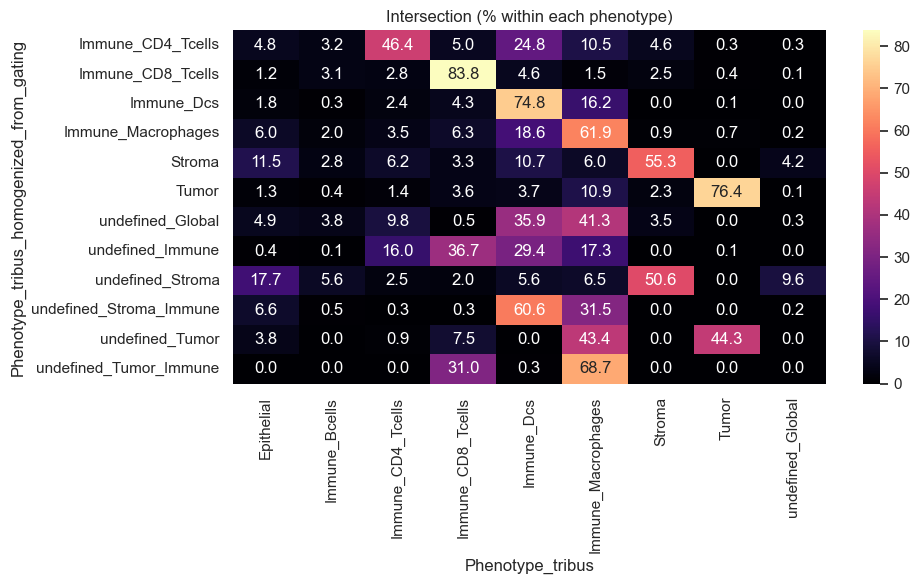

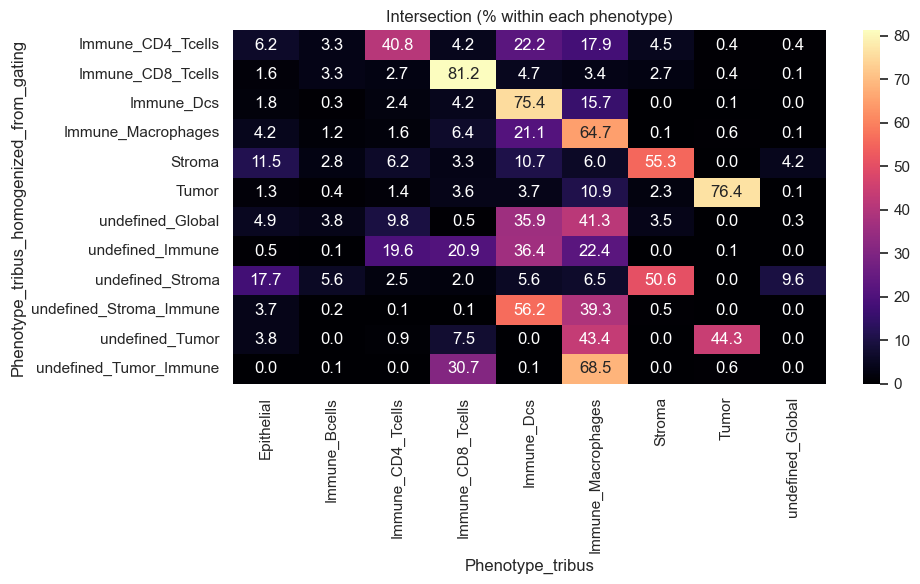

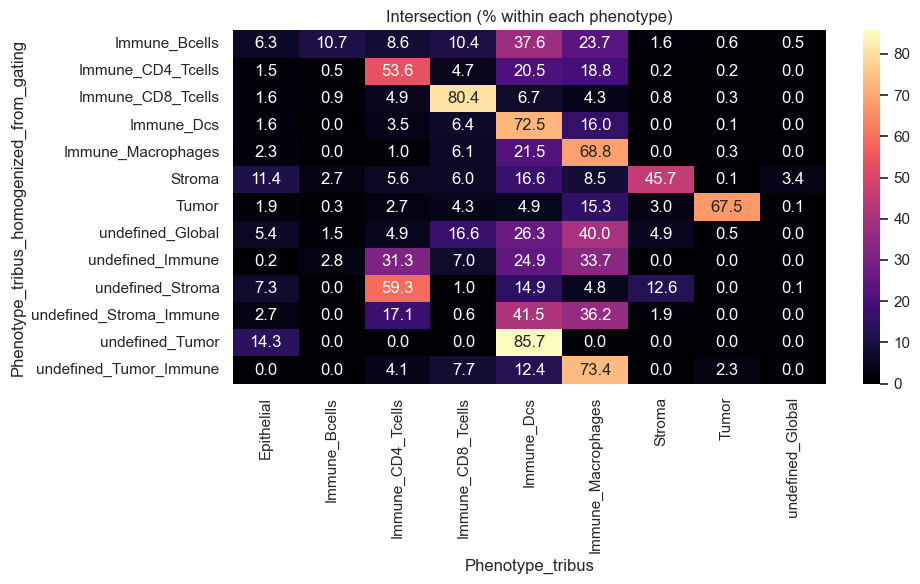

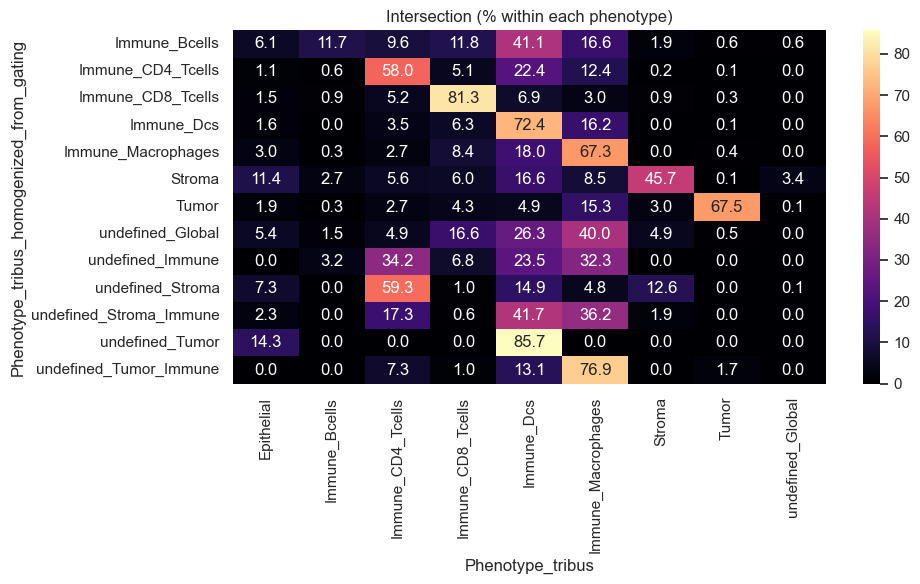

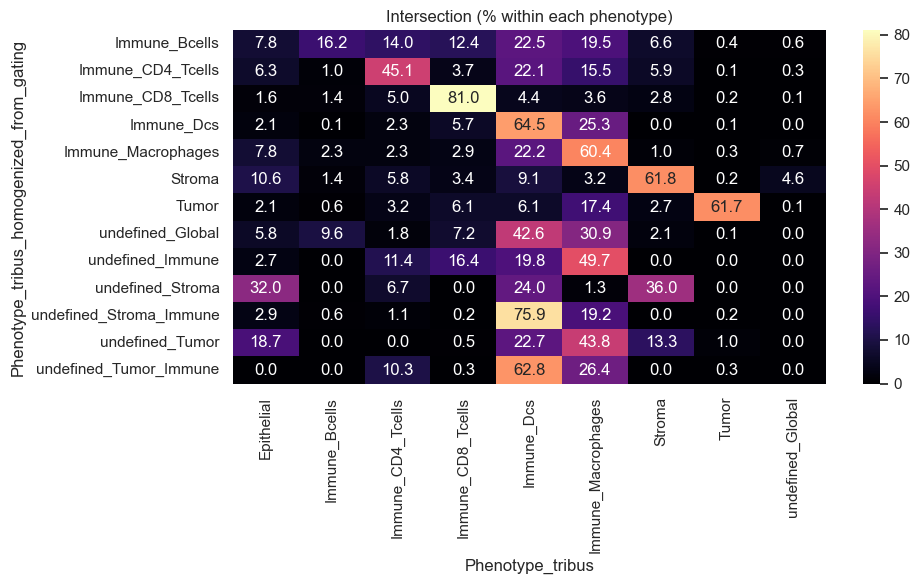

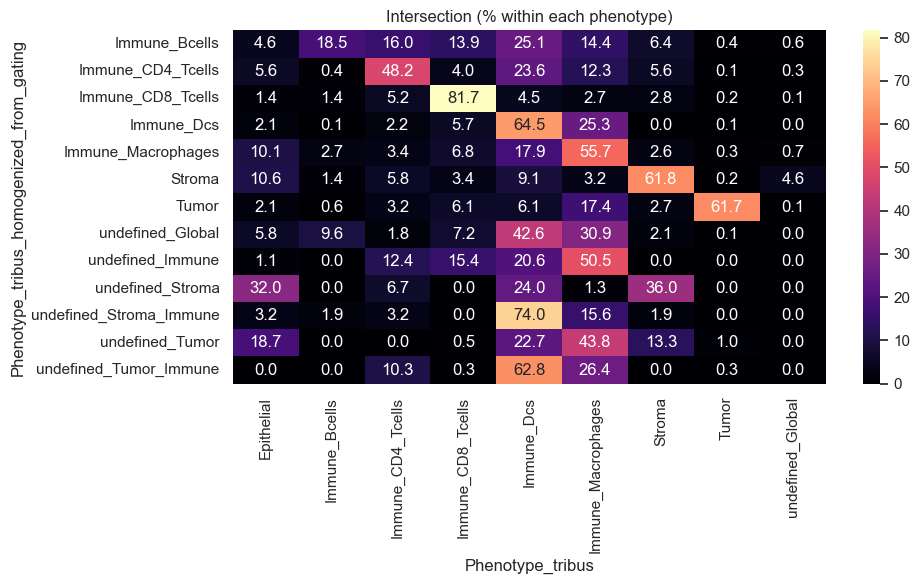

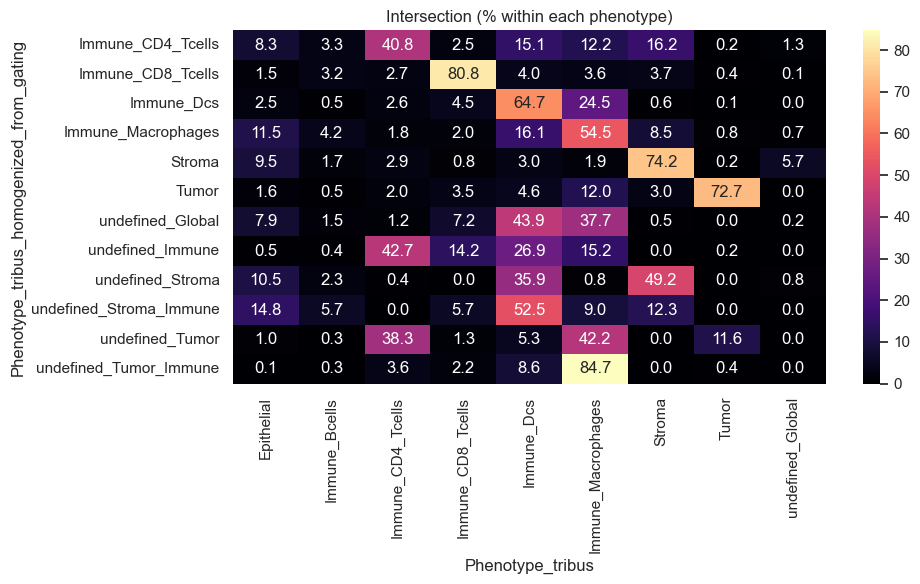

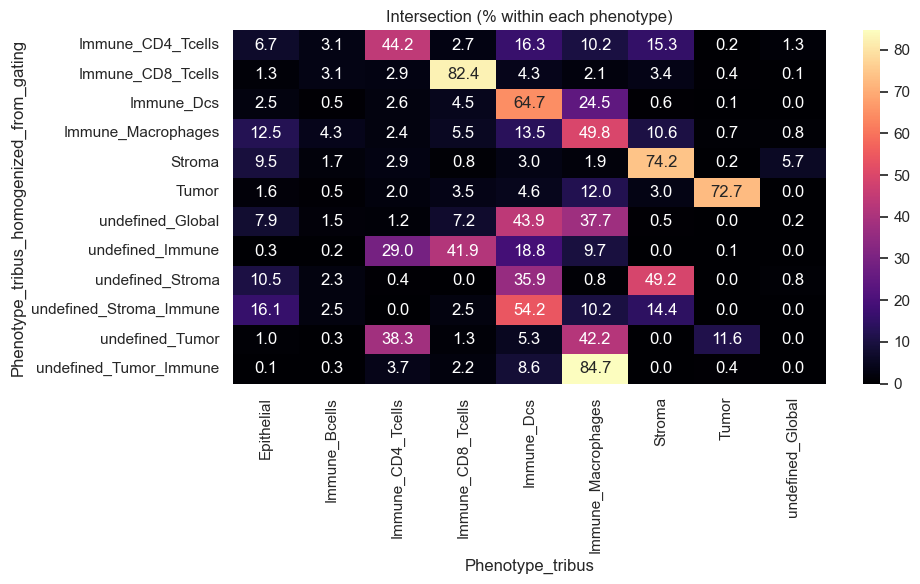

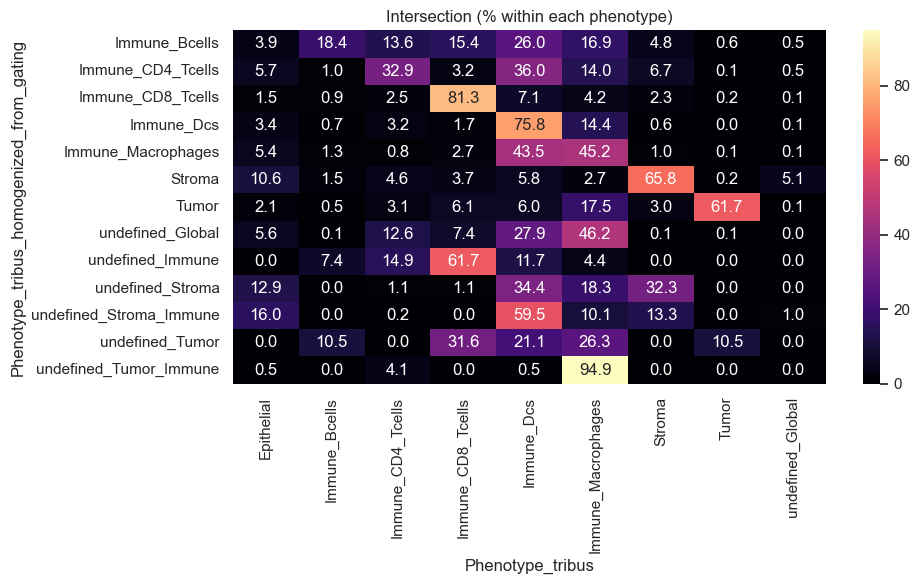

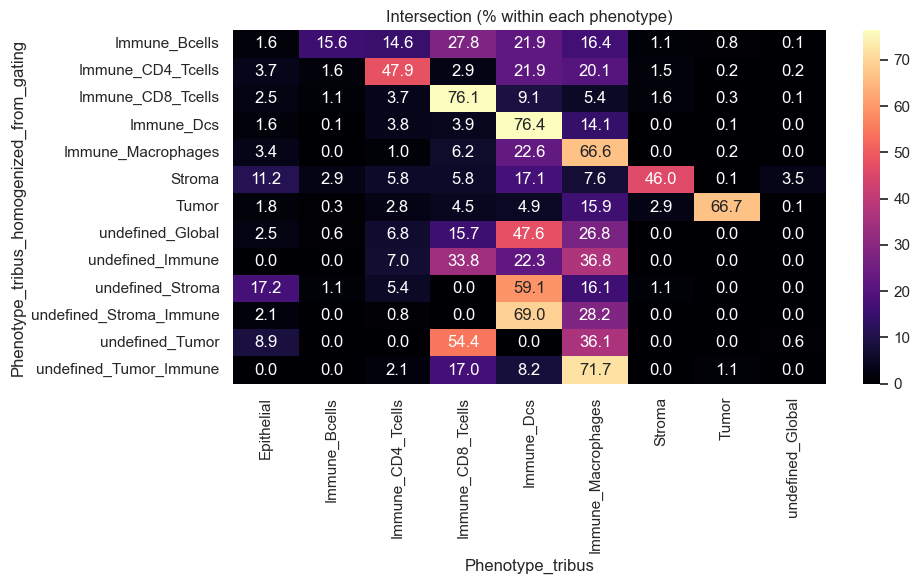

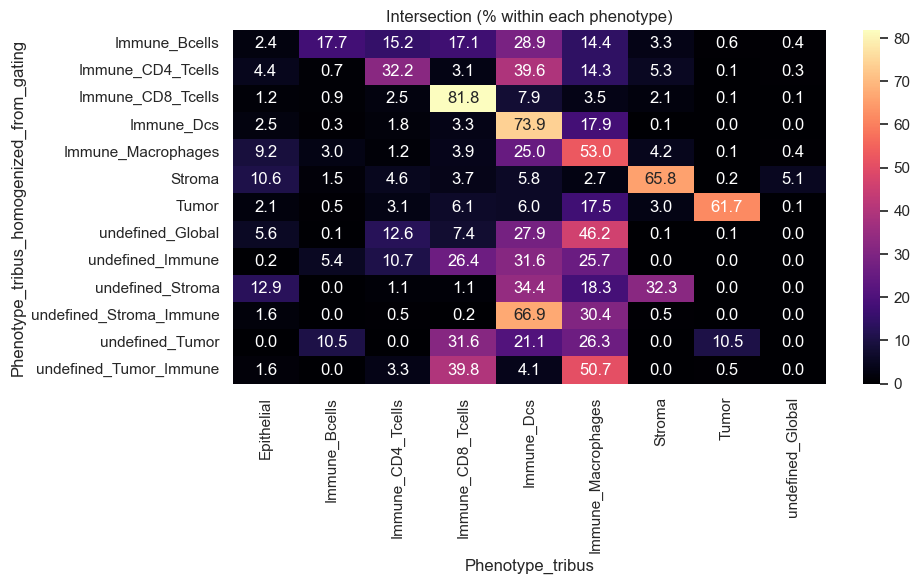

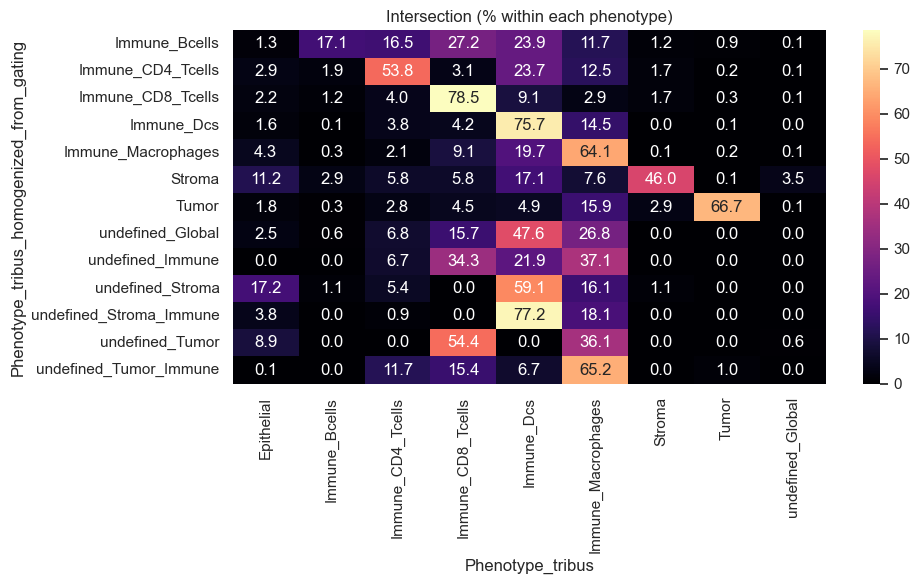

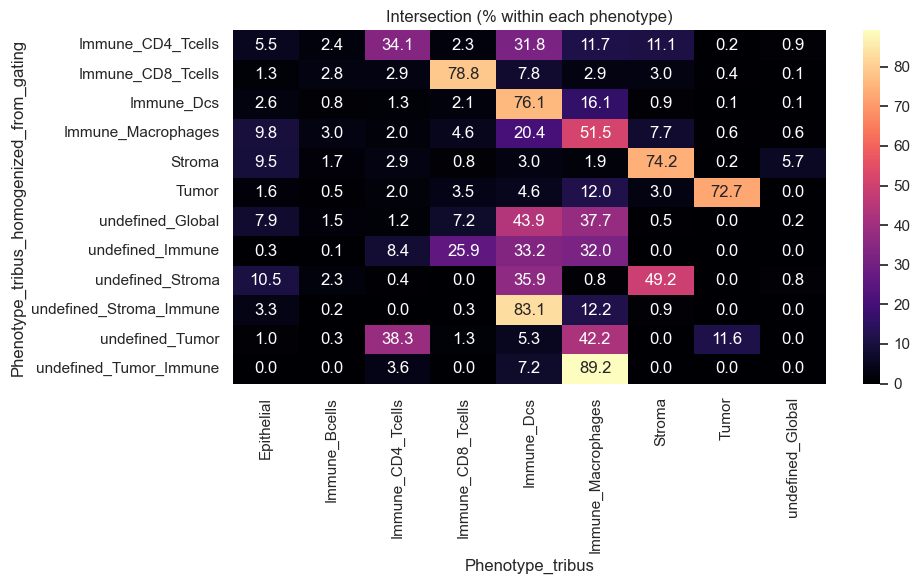

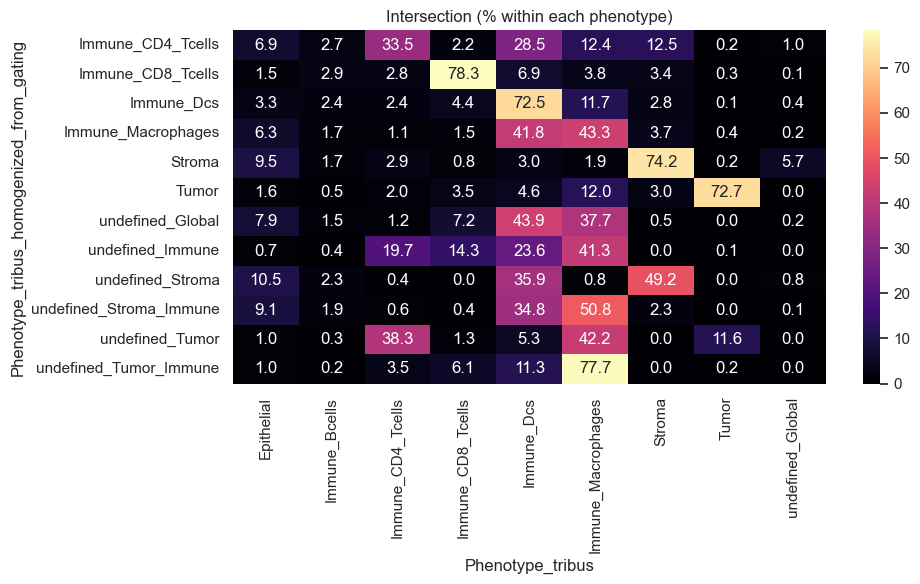

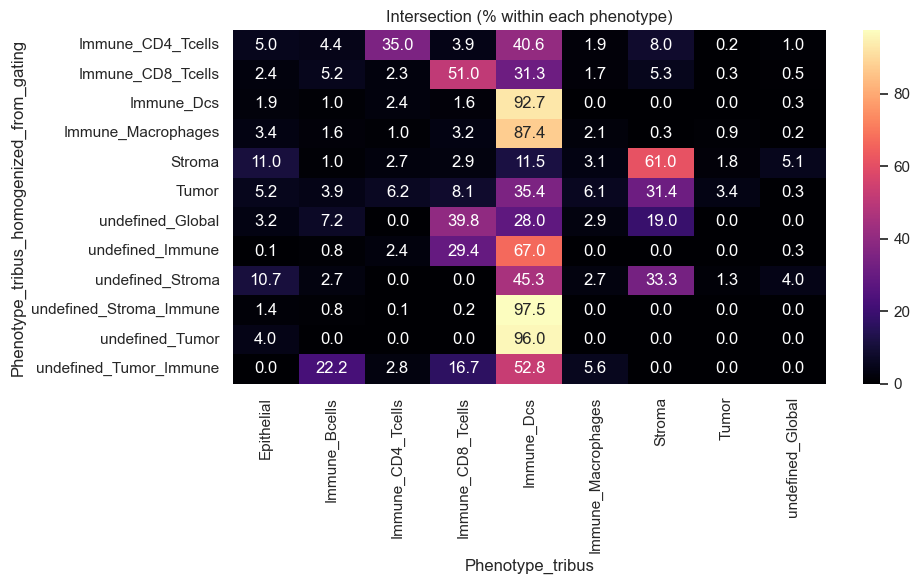

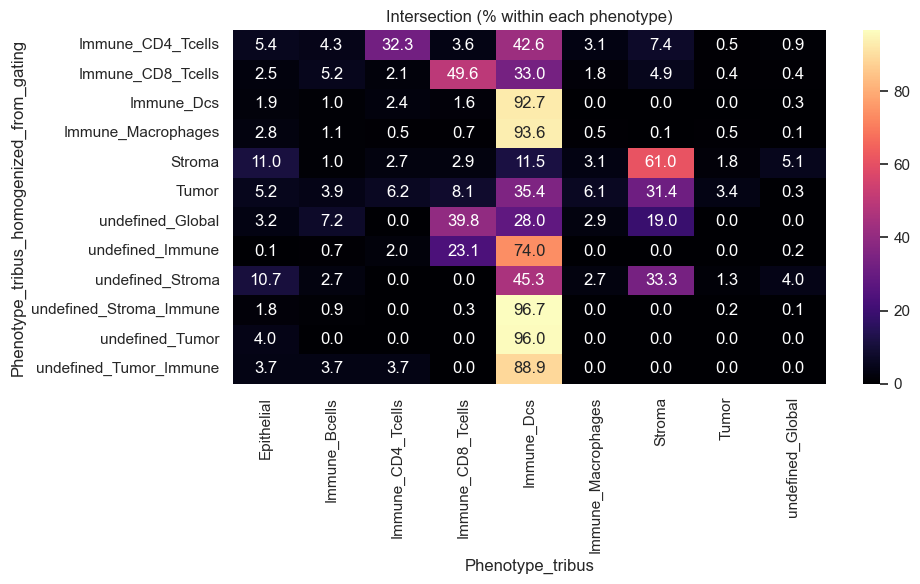

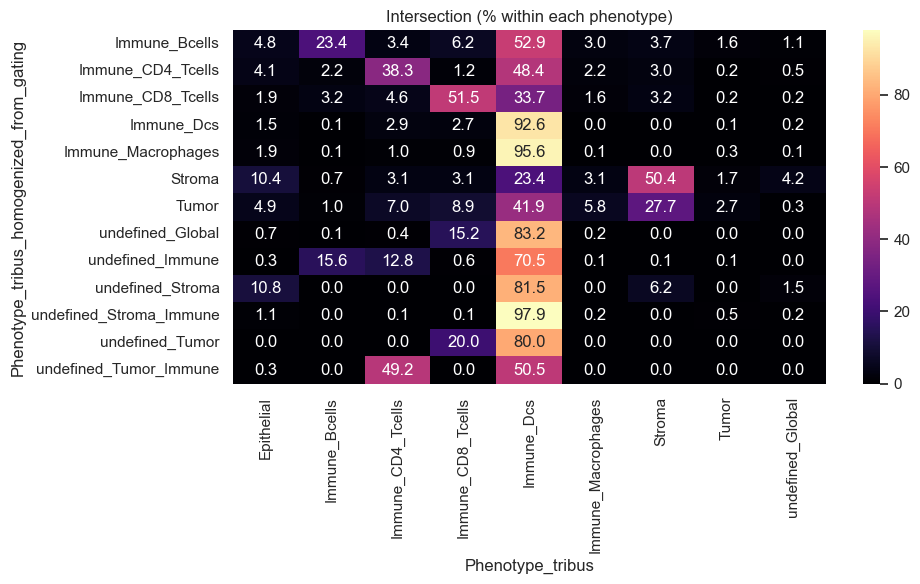

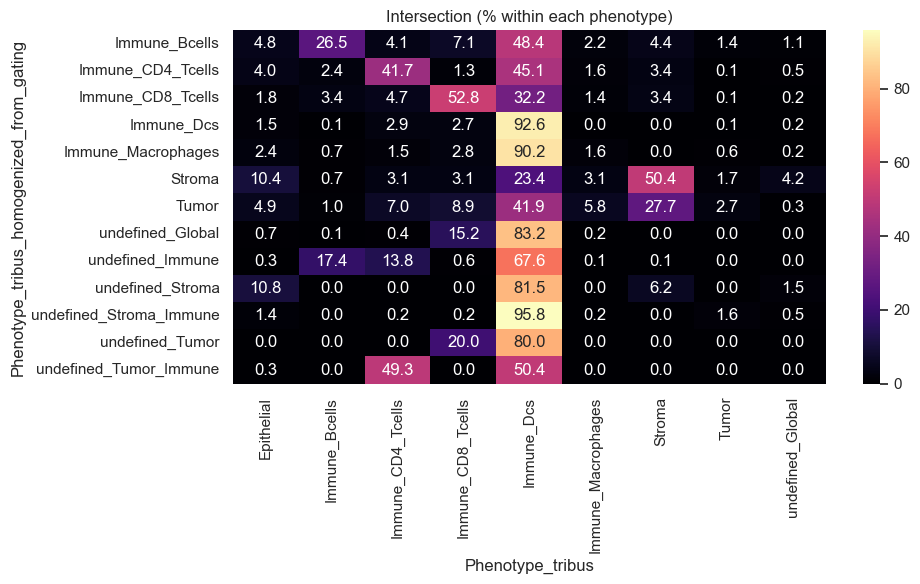

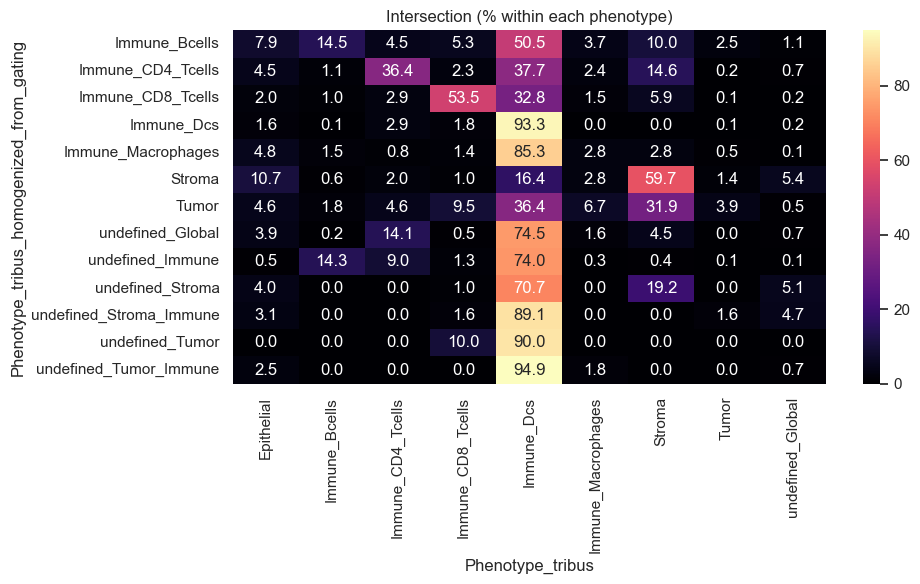

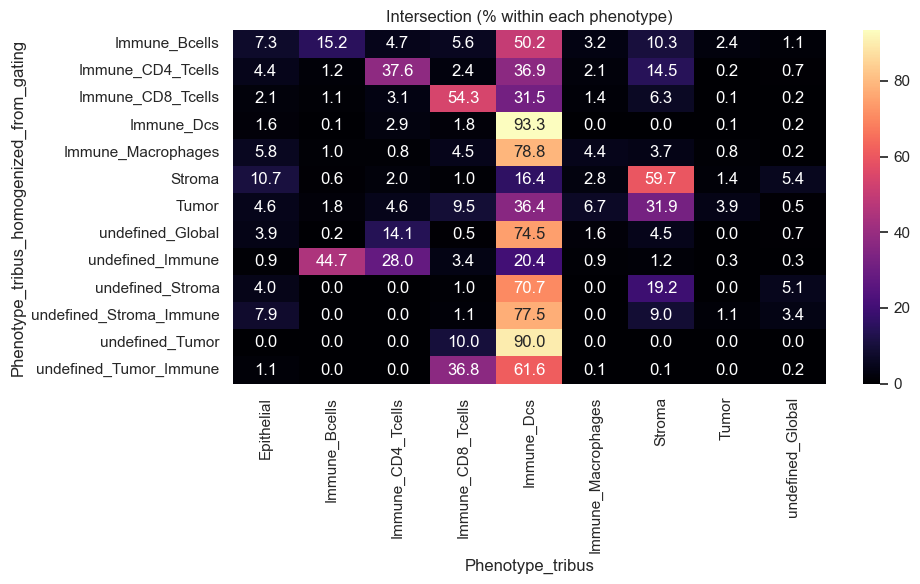

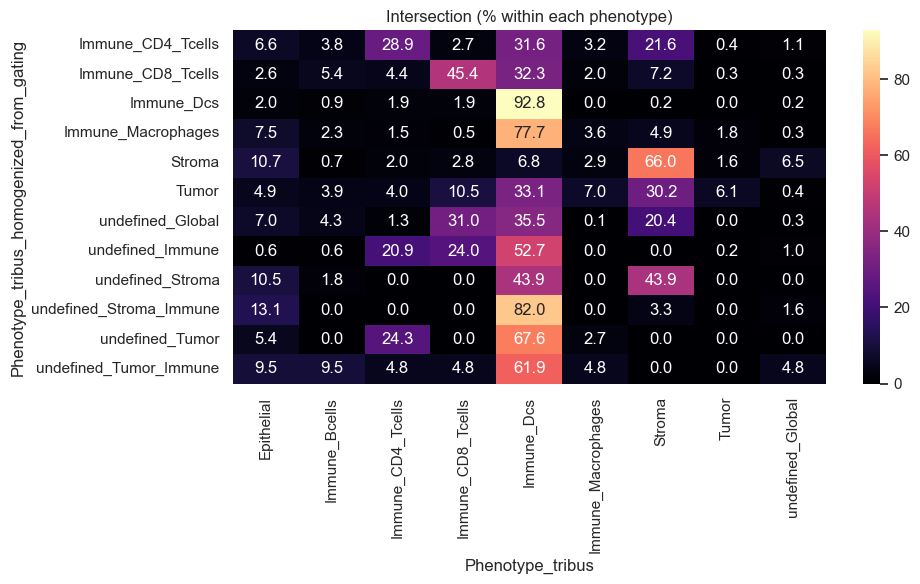

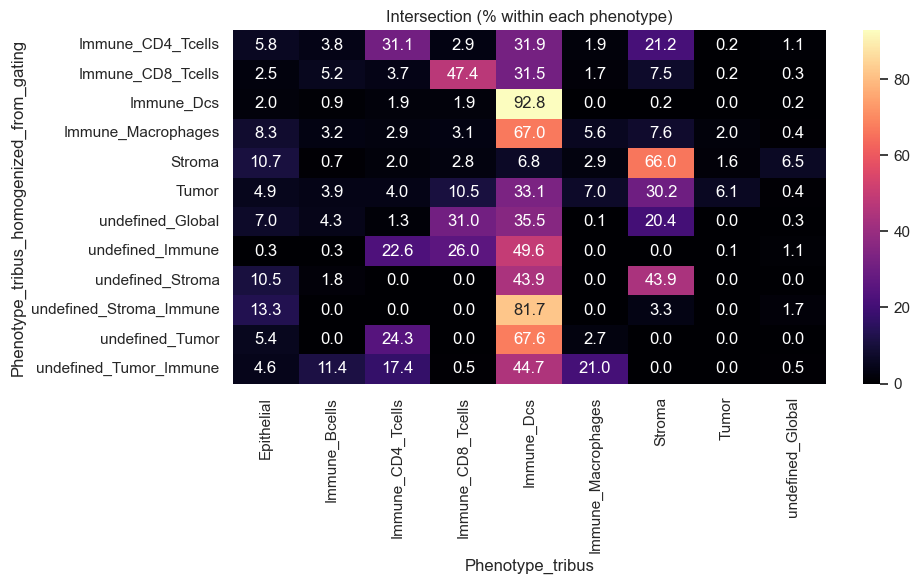

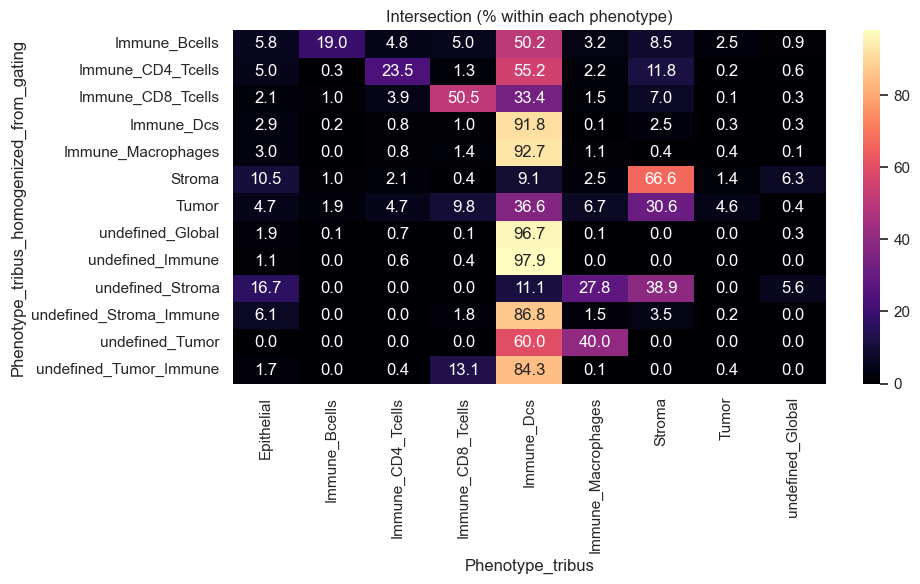

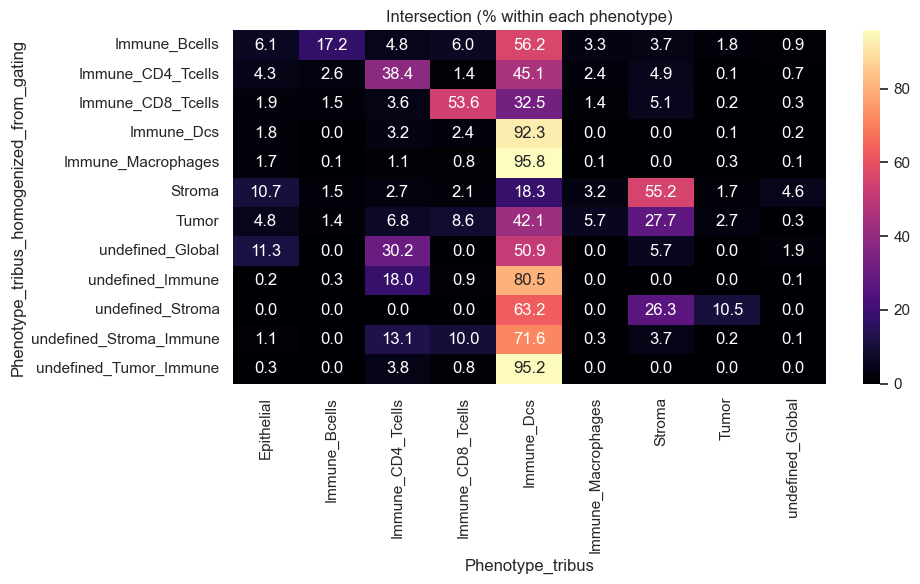

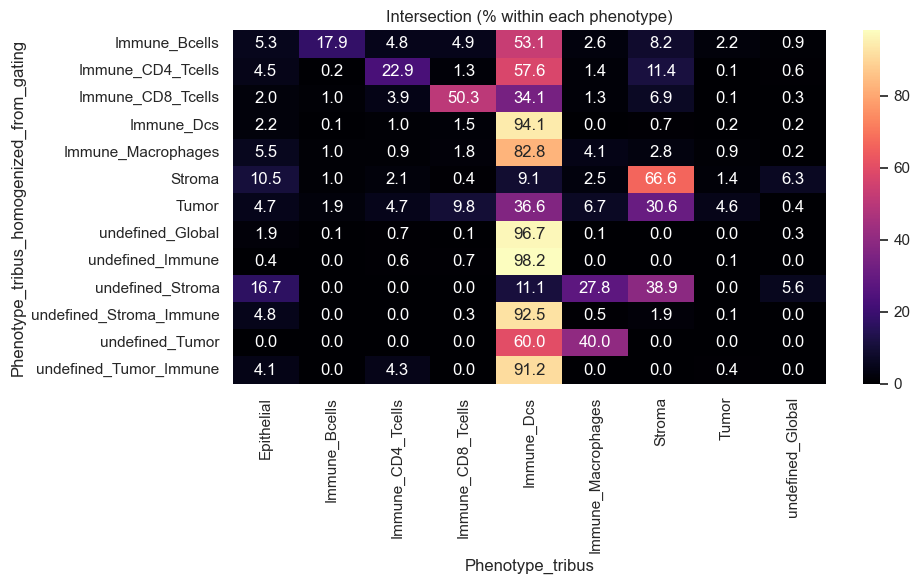

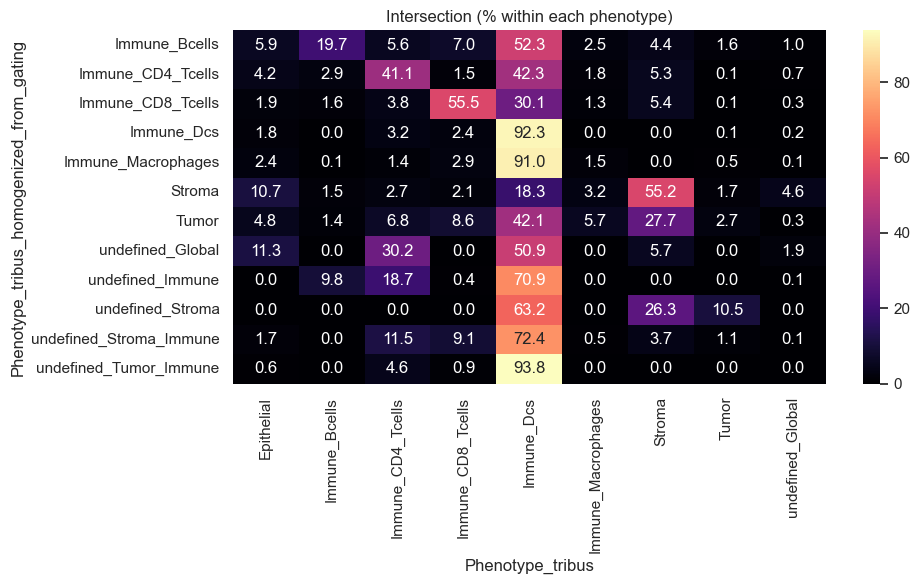

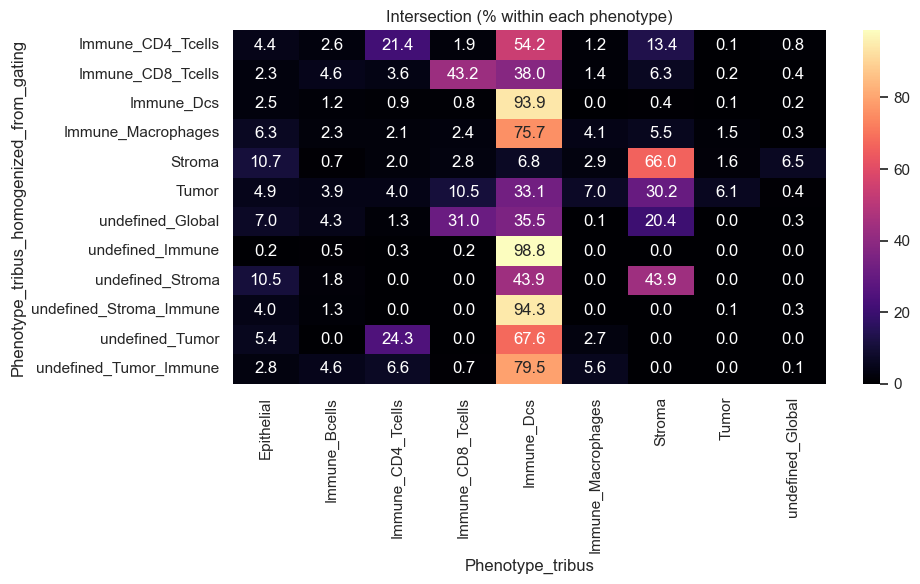

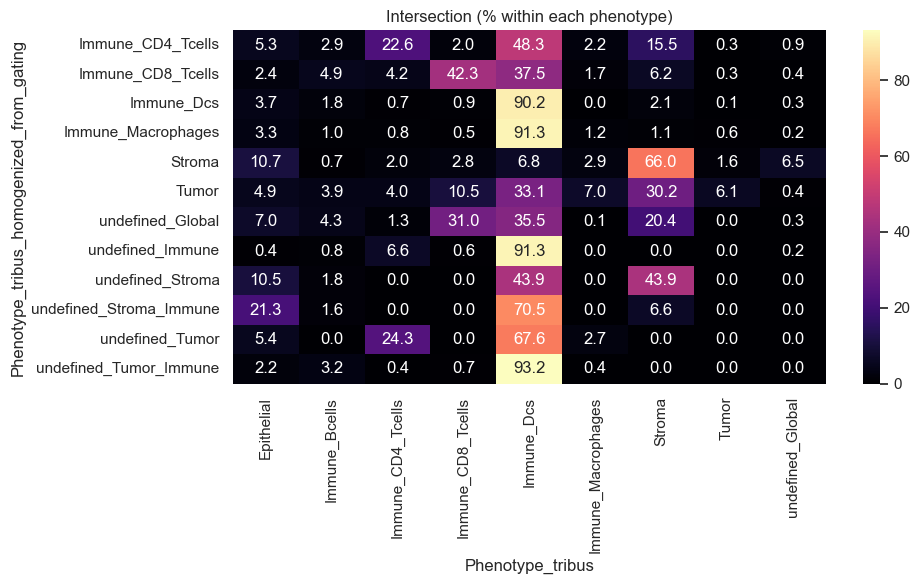

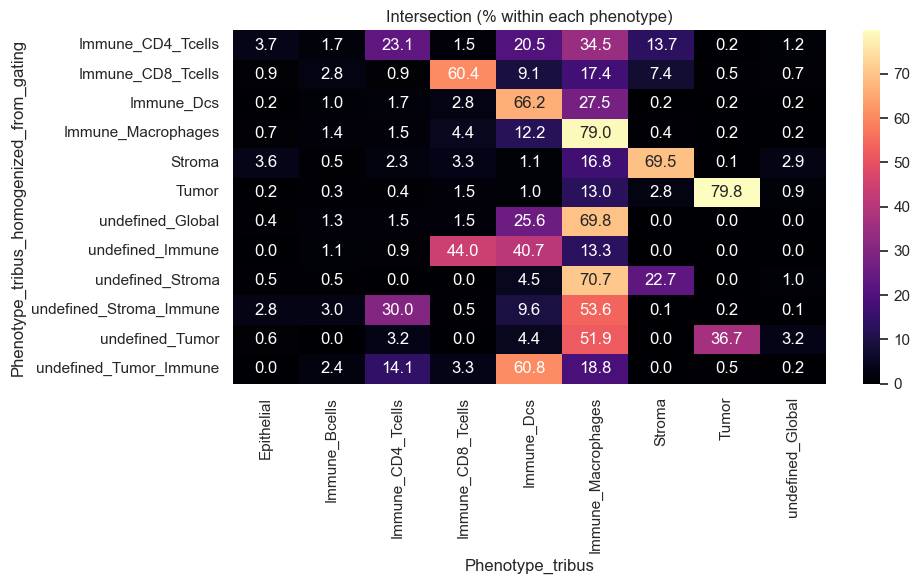

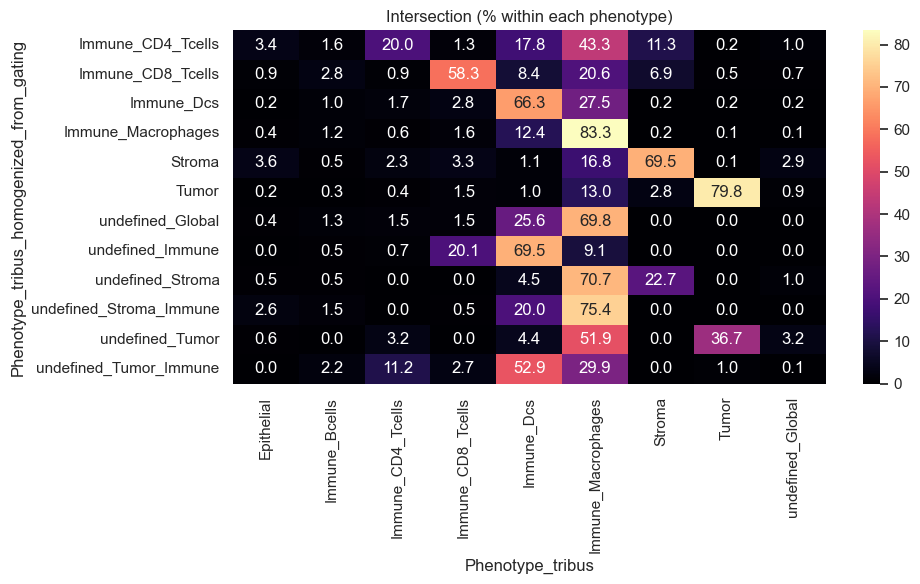

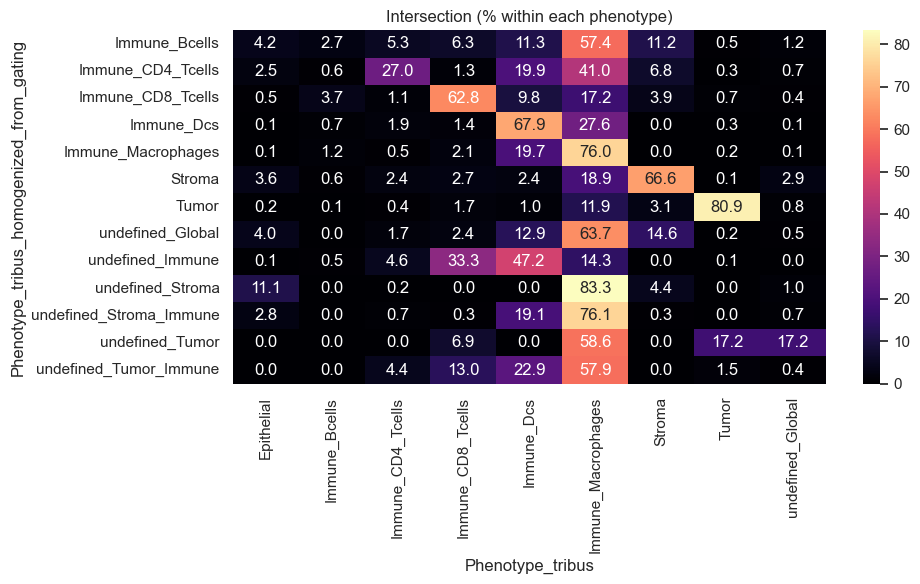

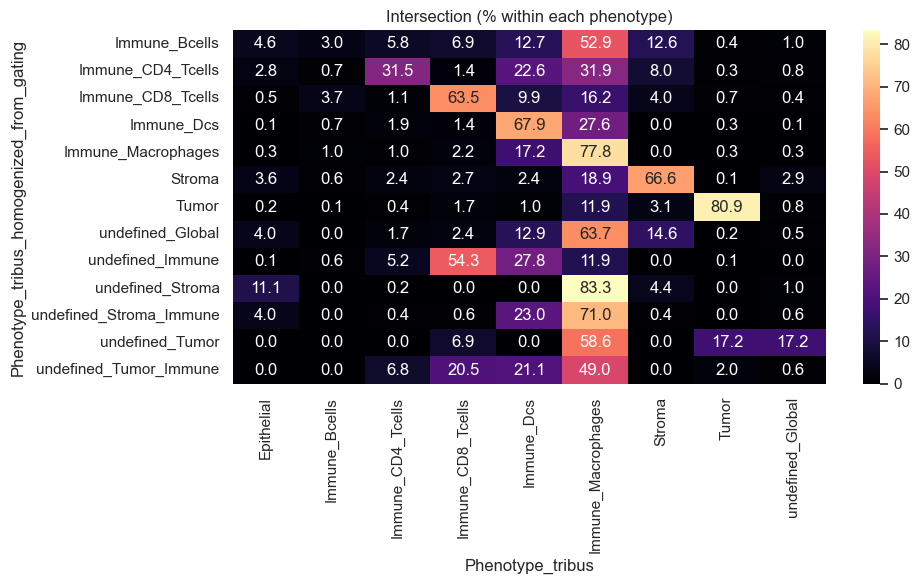

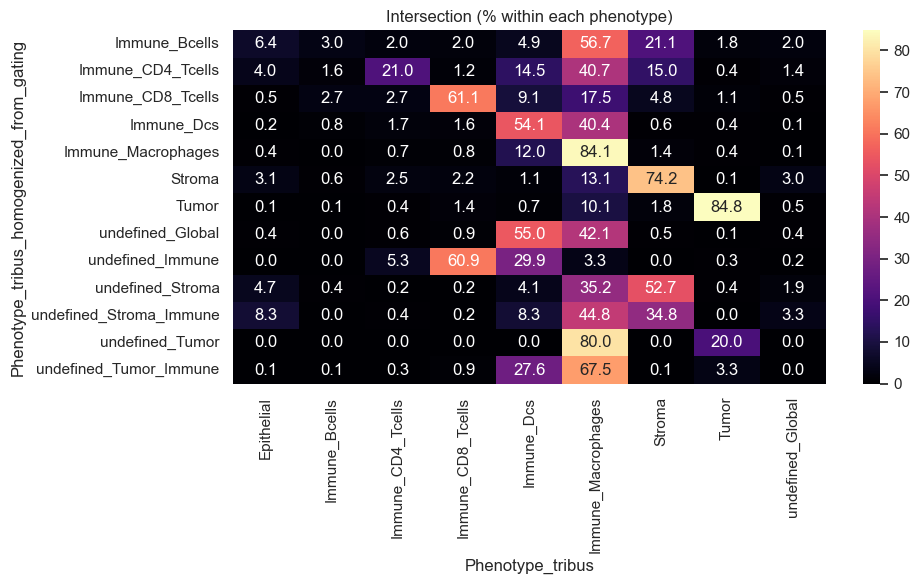

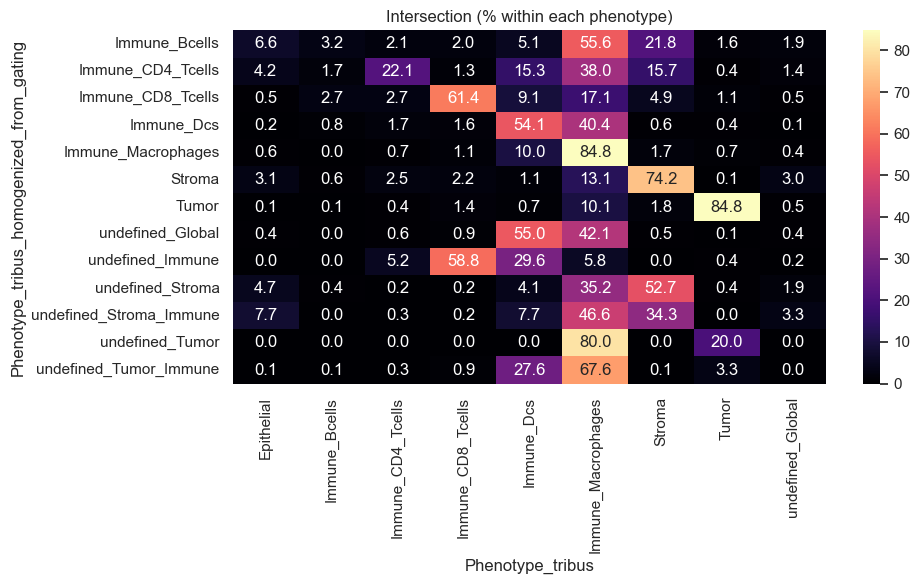

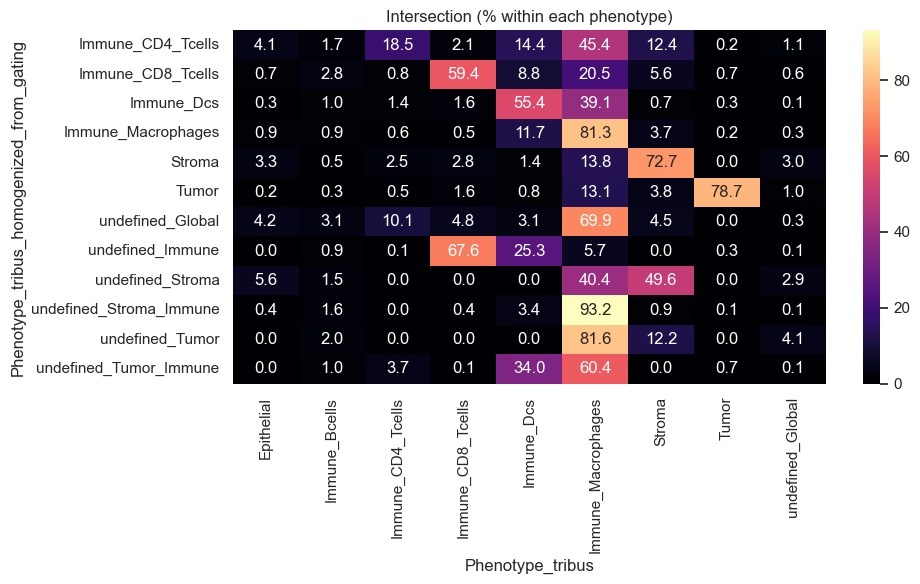

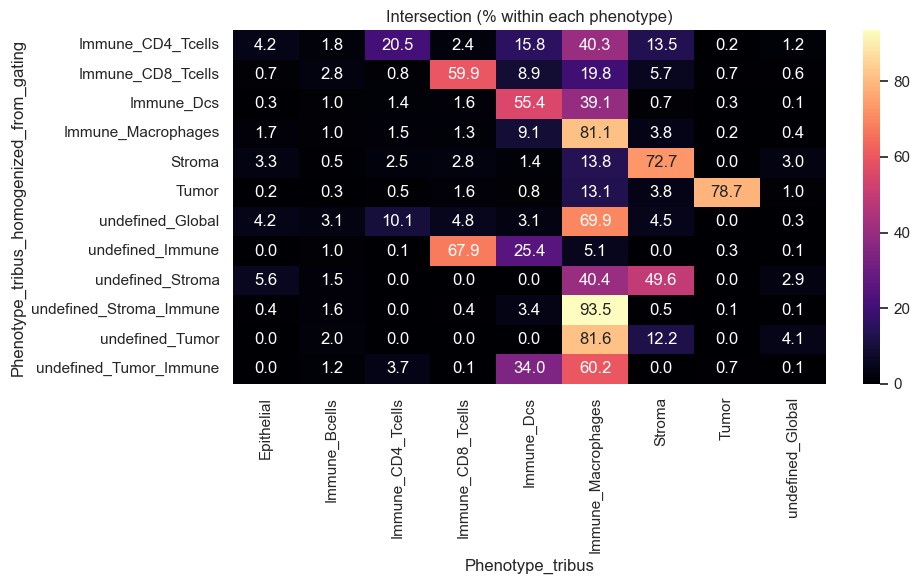

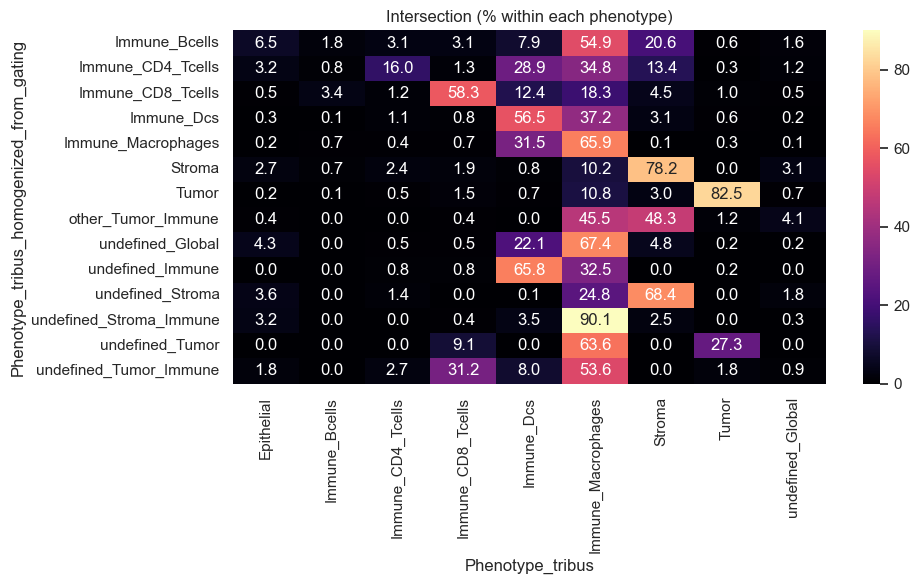

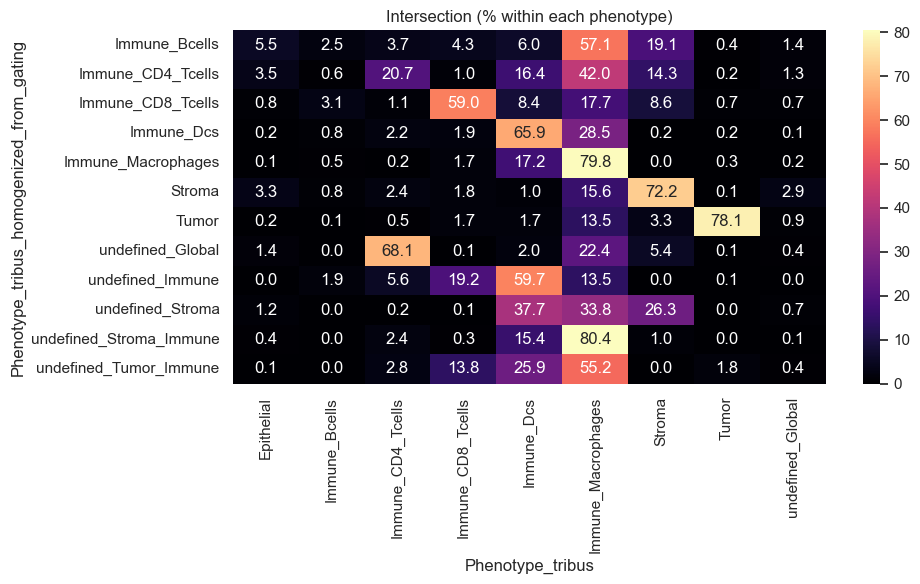

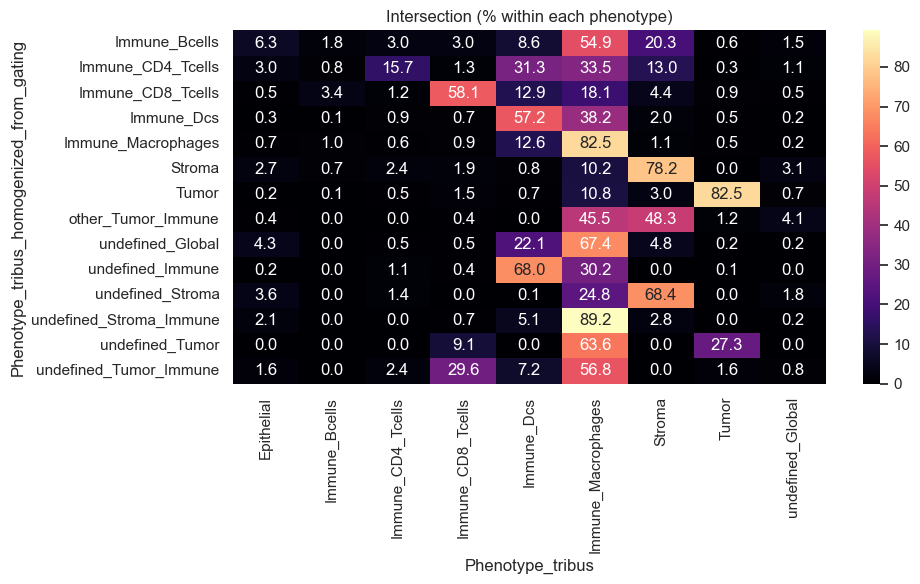

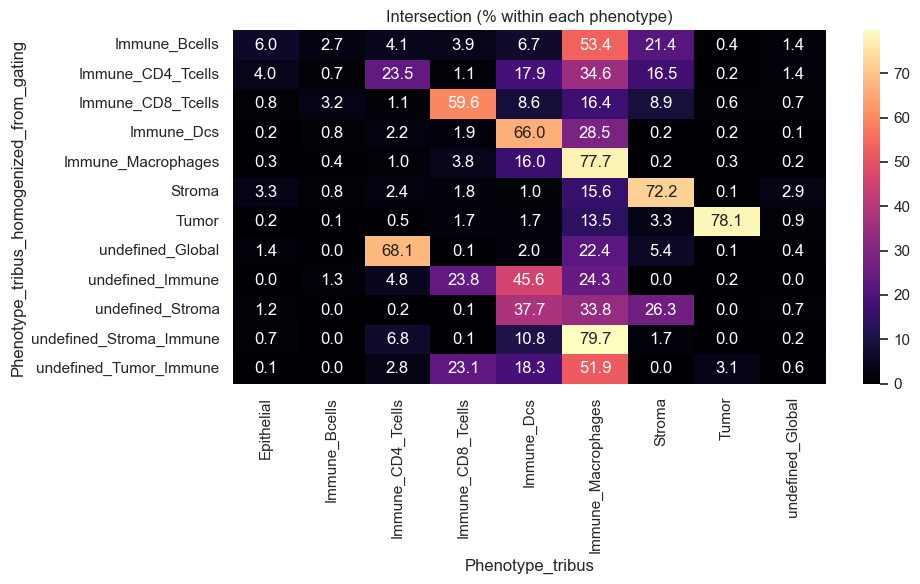

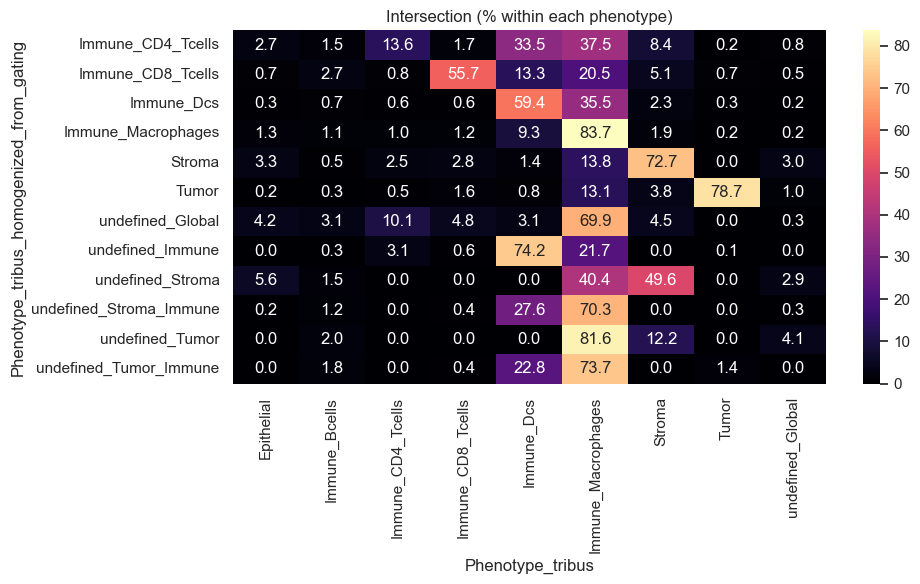

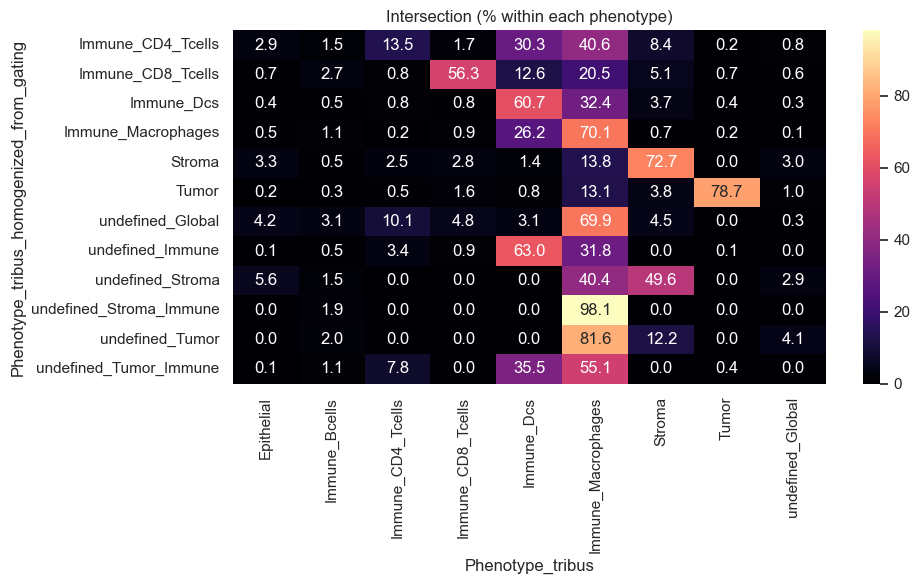

In [41]:
# heres the actual computing
# loop through patients
for pt_nr, pt_name in enumerate(pt_names):
    
    manual_gating_file = manual_gating_filenames[pt_nr]

    print(manual_gating_file)
    print(pt_name)

    tribus_output_pt = list(filter(re.compile('.*' + pt_name + '.*' + '_tribus_annotation.csv').match, tribus_output_list))
    print(len(tribus_output_pt))

    # loop through pt logic tables
    for tribus_pt_logic_path in tribus_output_pt:
    
        #tribus_pt_logic_path = tribus_output_pt[0]
        
        tribus_pt_logic_name = Path(tribus_pt_logic_path).stem.removesuffix('_tribus_annotation').removeprefix(pt_name)
        print(tribus_pt_logic_name)
        
        # read tribus output for given logic table 
        tribus_pt_logic = pd.read_csv(tribus_pt_logic_path)
        tribus_pt_logic.rename(columns={'final_label':'final_label_tribus'}, inplace=True)
        
        # rename categories not in line with gating
        tribus_pt_logic.final_label_tribus = tribus_pt_logic.final_label_tribus.replace(relabel_tribus_dict)
        
        # read manual gated sample
        # TODO read it in the outer loop to save time but for some reason just passing var fucks up anndata in the loop
        sample_data = ad.read_h5ad(manual_gating_file)  
        
        # check if cells id are the same
        print('CEllID match:')
        print(tribus_pt_logic.CellID.to_list() == sample_data.obs.CellID.to_list())
        print(tribus_pt_logic.shape)
        print(sample_data.obs.shape)
        
        # merge gated data with tribus output by CellID
        sample_data.obs = pd.merge(sample_data.obs, tribus_pt_logic[['CellID', 'final_label_tribus']])
        
        print(sample_data.obs.shape)
        
        # relabel manual gating to match tribus
        sample_data.obs["phenotype_tribus_homogenized"] = sample_data.obs["phenotype"].map(relabel_dict).fillna(sample_data.obs["phenotype"])
        
        # change new labs to categories
        sample_data.obs['phenotype_tribus_homogenized'] = sample_data.obs['phenotype_tribus_homogenized'].astype('category')
        sample_data.obs['final_label_tribus'] = sample_data.obs['final_label_tribus'].astype('category')
        
        # check categories
        print('CATEGORIES:')
        print(set(sample_data.obs.phenotype))
        print(set(sample_data.obs.phenotype_tribus_homogenized))
        print(set(sample_data.obs.final_label_tribus))
        
        # counts of labels in each category
        print("COUNTS OF PHENOTYPE LABELS")
        print(tribus_pt_logic['Global'].value_counts())
        print('###########')
        print(sample_data.obs['final_label_tribus'].value_counts())
        print('###########')
        print(sample_data.obs['phenotype_tribus_homogenized'].value_counts())
        print('###########')
        print(sample_data.obs['phenotype'].value_counts())

        # make umap plots with ct markers expression
        # TODO in the outer loop after fixing loading sample_data
        # TODO add checking for the filename - it takes a long time..
        #make_umap_w_markers(sample_data, output_comparison_plots_dir, pt_name,)
        
        # make umap plots colured by labels
        # if pt_name != "7-S026_iOme2_01253_4A":
        #     make_umap(sample_data, output_comparison_plots_dir, pt_name, tribus_pt_logic_name)
        
        # make heatmaps with comparison
        make_crosslabel_hmap(sample_data, output_comparison_plots_dir, pt_name, tribus_pt_logic_name)
        
        print('######################')


In [9]:
# one pt testing

pt_nr = 0
pt_name = pt_names[pt_nr]

manual_gating_file = manual_gating_filenames[pt_nr]

print(manual_gating_file)
print(pt_name)

tribus_output_pt = list(filter(re.compile('.*' + pt_name + '.*' + '_tribus_annotation.csv').match, tribus_output_list))
print(len(tribus_output_pt))

tribus_pt_logic_path = tribus_output_pt[0]


tribus_pt_logic_name = Path(tribus_pt_logic_path).stem.removesuffix('_tribus_annotation').removeprefix(pt_name)
print(tribus_pt_logic_name)
        
# read tribus output for given logic table 
tribus_pt_logic = pd.read_csv(tribus_pt_logic_path)
tribus_pt_logic.rename(columns={'final_label':'final_label_tribus'}, inplace=True)

# rename categories not in line with gating
tribus_pt_logic.final_label_tribus = tribus_pt_logic.final_label_tribus.replace(relabel_tribus_dict)

# read manual gated sample
# TODO read it in the outer loop to save time but for some reason just passing var fucks up anndata in the loop
sample_data = ad.read_h5ad(manual_gating_file)  

# check if cells id are the same
print('CEllID match:')
print(tribus_pt_logic.CellID.to_list() == sample_data.obs.CellID.to_list())
print(tribus_pt_logic.shape)
print(sample_data.obs.shape)

# merge gated data with tribus output by CellID
sample_data.obs = pd.merge(sample_data.obs, tribus_pt_logic[['CellID', 'final_label_tribus']])

print(sample_data.obs.shape)

# relabel manual gating to match tribus
sample_data.obs["phenotype_tribus_homogenized"] = sample_data.obs["phenotype"].map(relabel_dict).fillna(sample_data.obs["phenotype"])

# change new labs to categories
sample_data.obs['phenotype_tribus_homogenized'] = sample_data.obs['phenotype_tribus_homogenized'].astype('category')
sample_data.obs['final_label_tribus'] = sample_data.obs['final_label_tribus'].astype('category')

print(sample_data)
print(sample_data.obsm)

# check categories
print('CATEGORIES:')
print(set(sample_data.obs.phenotype))
print(set(sample_data.obs.phenotype_tribus_homogenized))
print(set(sample_data.obs.final_label_tribus))

# counts of labels in each category
print("COUNTS OF PHENOTYPE LABELS")
print(tribus_pt_logic['Global'].value_counts())
print('###########')
print(sample_data.obs['final_label_tribus'].value_counts())
print('###########')
print(sample_data.obs['phenotype_tribus_homogenized'].value_counts())
print('###########')
print(sample_data.obs['phenotype'].value_counts())

# make umap plots with ct markers expression
# TODO in the outer loop after fixing loading sample_data
# TODO add checking for the filename - it takes a long time..
#make_umap_w_markers(sample_data, output_comparison_plots_dir, pt_name,)

# make umap plots colured by labels
# make_umap(sample_data, output_comparison_plots_dir, pt_name, tribus_pt_logic_name)

# # make heatmaps with comparison
# make_crosslabel_hmap(sample_data, output_comparison_plots_dir, pt_name, tribus_pt_logic_name)


/home/ad/P-drive/h30492/farkkilab2/7_TLS/Data/Exp_4/cell-phenotyping/gating_results/S026_1.h5ad
7-S026_iOme1_01253_4A
2
eyemt_tribus_global_neg_stroma_neg_tumor_zero_immune_zero_nkdrop
CEllID match:
True
(474256, 9)
(474256, 9)
(474256, 10)
AnnData object with n_obs × n_vars = 474256 × 17
    obs: 'CellID', 'sample_id', 'Sample', 'X_centroid', 'Y_centroid', 'Area', 'Eccentricity', 'imageid', 'phenotype', 'final_label_tribus', 'phenotype_tribus_homogenized'
    uns: 'gates', 'neighbors', 'pca', 'phenotype_colors', 'umap'
    obsm: 'X_pca', 'X_umap', 'umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'
AxisArrays with keys: X_pca, X_umap, umap
CATEGORIES:
{'likely-CD11c+ DCs', 'IBA1+ macrophages', 'CD4+ T cells', 'HEV+ CD31+ cells', 'Stromal', 'CD11c+ DCs', 'Cancer', 'Myeloids2', 'CD31+ cells', 'Cancer Ki67+', 'CD21+ CD20+ B cells', 'Unknown', 'CD20+ B cells', 'CD8+ T cells'}
{'undefined_Global', 'Tumor', 'Stroma', 'Immune_Macrophages', 'Immune_CD8_Tcells', 'Immune_CD4_Tcells',

In [ ]:
# # Generate Clustree plot
# fig = clustree(
#     sample_data,
#     ["phenotype", "phenotype_tribus_homogenized"],  # Include manual and PRIMUS in hierarchy
#     title="Clustree Plot with Manual Clusters & PRIMUS",
#     edge_weight_threshold=0.1,  # Show edges over 10%
#     show_fraction=False,  # Show proportion of cells per cluster
#     graph_plot_kwargs={"font_color": "black", "font_size": 10, "alpha": 0.75,"edge_cmap":sns.color_palette("viridis", as_cmap=True)},
# )

# # Adjust figure dimensions
# fig.set_size_inches(26, 5)  # Width=12, Height=8 (Modify as needed)
# plt.show()

In [ ]:

# # Crosstab of counts
# intersection_counts = pd.crosstab(
#     sample_data.obs["phenotype_tribus_homogenized"],
#     sample_data.obs["final_label_tribus"]
# )

# # Normalize by total (grand total %)
# intersection_pct_total = intersection_counts.div(intersection_counts.sum().sum()) * 100

# # Normalize by row (within each phenotype %)
# intersection_pct_row = intersection_counts.div(intersection_counts.sum(axis=1), axis=0) * 100

# # Plot: row-wise %
# plt.figure(figsize=(10,6))
# sns.heatmap(intersection_pct_row, annot=True, fmt=".1f", cmap="magma")
# plt.title("Intersection (% within each phenotype)")
# plt.ylabel("Phenotype_tribus_homogenized")
# plt.xlabel("Phenotype_gating")
# plt.tight_layout()
# plt.show()
# plt.savefig(os.path.join(output_comparison_plots_dir, pt_name + '_heatmap_' + tribus_output_pt_logic_name + '.png'))


In [10]:
# # Image inspection

file_image_dir = os.path.join(image_dir, pt_name + ".ome.tif")

marker_list_with_DNA = ['DAPI1', 'BCL6', 'IgG', 'AICDA', 'CD138', 'DAPI2', 'Tcf1',
       'FOXP3', 'PD1', 'CD45', 'DAPI3', 'CD21', 'Ki-67', 'CD20', 'Vimentin',
       'DAPI4', 'CD4', 'CD11c', 'CD8a', 'DAPI5', 'HEV', 'PanCK', 'CD31',
       'DAPI6', 'Iba1', 'CD3D', 'IgD', 'DAPI7', 'aSMA', 'HLA-DPB2', 'HLA-A','DAPI8', 'CD68', 'PAX8', 'NKG2A', 'DAPI9', 'CD163', 'FAP', 'PAX8_2']

sm.pl.image_viewer(file_image_dir, sample_data, overlay = 'phenotype', channel_names = marker_list_with_DNA,x_coordinate="X_centroid",y_coordinate="Y_centroid", point_size=5)



NameError: name 'napari' is not defined

In [ ]:
# 7-S026_iOme1_01253_4A
# 6
# eyemt_tribus_global_neg_stroma_neg_tumor_zero_immune_zero_nkdrop
# CEllID match:
# True
# (474256, 9)
# (474256, 9)
# (474256, 10)
# AnnData object with n_obs × n_vars = 474256 × 17
#     obs: 'CellID', 'sample_id', 'Sample', 'X_centroid', 'Y_centroid', 'Area', 'Eccentricity', 'imageid', 'phenotype', 'final_label_tribus', 'phenotype_tribus_homogenized'
#     uns: 'gates', 'neighbors', 'pca', 'phenotype_colors', 'umap'
#     obsm: 'X_pca', 'X_umap', 'umap'
#     varm: 'PCs'
#     obsp: 'connectivities', 'distances'
# AxisArrays with keys: X_pca, X_umap, umap

#################
# /home/ad/P-drive/h30492/farkkilab2/7_TLS/Data/Exp_4/cell-phenotyping/gating_results/S026_2.h5ad
# 7-S026_iOme2_01253_4A
# 6
# eyemt_tribus_global_neg_stroma_neg_tumor_zero_immune_zero_nkdrop
# CEllID match:
# True
# (270269, 9)
# (270269, 11)
# (270269, 12)
# AnnData object with n_obs × n_vars = 270269 × 17
#     obs: 'Area', 'CellID', 'Eccentricity', 'Sample', 'X_centroid', 'Y_centroid', '_index', 'imageid', 'phenotype', 'phenotype_tribus', 'sample_id', 'final_label_tribus', 'phenotype_tribus_homogenized'
# AxisArrays with keys: 